# EKE as a function of physical depth

This notebook calculates horizontal EKE at each saved vertical level. The NetCDF `diag_levels` values are treated as **1-based model-level indices**. Physical cell-centre depths are reconstructed from the hard-coded `delR` array assigned to each case.

$$\mathrm{EKE}(z)=\frac{1}{2}\left\langle (u-\langle u\rangle_{x,y})^2+(v-\langle v\rangle_{x,y})^2\right\rangle_{x,y}.$$


In [13]:
from pathlib import Path
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

# ============================================================
# SETTINGS
# ============================================================

NB_DIR = Path.cwd()
DATA_DIR = (NB_DIR / "../data/input").resolve()

# Select the NetCDF files to compare.
CASE_FILES = {
    "Reference, V84": DATA_DIR / "run_aug1_spinup.nc",
    "V42": DATA_DIR / "run_aug1_V42_spinup.nc",
    "V36": DATA_DIR / "run_aug1_V36_spinup.nc",
    "V30": DATA_DIR / "run_aug1_V30_spinup.nc",
    "V24": DATA_DIR / "run_aug1_V24_spinup.nc",
    "V18": DATA_DIR / "run_aug1_V18_spinup.nc",
}

TIME_INDEX = 0
MAX_PLOT_DEPTH_M = None

# ============================================================
# VERTICAL DISCRETIZATIONS: delR [m]
# ============================================================

V84 = np.array([
    2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0,
    2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0,
    2.0, 2.0, 2.0, 2.0, 2.0, 2.2, 2.4, 2.6, 2.9, 3.1,
    3.4, 3.7, 4.0, 4.4, 4.8, 5.2, 5.7, 6.2, 6.8, 7.4,
    8.1, 8.8, 9.6, 10.5, 11.4, 12.5, 13.6, 14.8, 16.2, 17.6,
    19.2, 21.0, 22.9, 24.9, 27.2, 29.7, 32.4, 35.4, 38.6, 42.1,
    45.9, 50.0, 54.5, 59.4, 64.8, 70.6, 77.0, 84.0, 91.5, 99.7,
    108.7, 118.5, 129.1, 140.8, 153.5, 167.3, 182.4, 198.8, 216.7, 236.2,
    257.5, 280.7, 306.1, 328.5
], dtype=float)

V42 = np.array([
    *([2.0] * 25),
    2.200,
    3.282, 4.895, 7.301, 10.890,
    16.244, 24.230, 36.141, 53.908,
    80.410, 119.940, 178.903, 266.853,
    398.039, 593.717, 885.592, 1320.955
], dtype=float)

V36 = np.array([
    *([4.0] * 12),
    4.400, 4.840, 5.324,
    6.784, 8.645, 11.016, 14.037, 17.887,
    22.792, 29.043, 37.009, 47.159, 60.093,
    76.574, 97.575, 124.336, 158.437, 201.889,
    257.260, 327.816, 417.723, 532.289,
    678.274, 864.298
], dtype=float)

V30 = np.array([
    *([6.0] * 8),
    6.600, 7.260,
    9.214, 11.694, 14.842, 18.838,
    23.908, 30.344, 38.511, 48.878,
    62.035, 78.733, 99.926, 126.823,
    160.961, 204.288, 259.278, 329.069,
    417.646, 530.067, 672.748, 853.837
], dtype=float)

V24 = np.array([
    *([8.0] * 6),
    8.800, 9.680,
    12.947, 17.318, 23.164, 30.982,
    41.441, 55.429, 74.139, 99.164,
    132.637, 177.409, 237.293, 317.391,
    424.526, 567.825, 759.494, 1015.861
], dtype=float)

V18 = np.array([
    *([12.5] * 4),
    13.750,
    19.352, 27.235, 38.330, 53.946,
    75.923, 106.852, 150.383, 211.647,
    297.869, 419.217, 590.001, 830.359,
    1168.636
], dtype=float)

# The keys here must match CASE_FILES.
DELR_BY_CASE = {
    "Reference, V84": V84,
    "V42": V42,
    "V36": V36,
    "V30": V30,
    "V24": V24,
    "V18": V18,
}


In [14]:
def layer_center_depths(delR):
    """Return positive-down MITgcm cell-centre depths [m]."""
    delR = np.asarray(delR, dtype=float)
    return np.cumsum(delR) - 0.5 * delR


def calculate_eke_profile(filepath, delR, time_index=0):
    """
    Calculate horizontal EKE as a function of physical depth.

    diag_levels is interpreted as 1-based model-level indices.
    The corresponding physical depths are obtained from delR.
    """
    filepath = Path(filepath)
    delR = np.asarray(delR, dtype=float)

    with xr.open_dataset(filepath, decode_times=False) as ds:
        u = ds["UVEL"]
        v = ds["VVEL"]

        # Find diagnostic vertical dimension.
        depth_dim = next(
            dim for dim in u.dims
            if dim.startswith("Z") or "depth" in dim.lower()
        )

        # Read saved model-level indices from the NetCDF.
        if "diag_levels" in ds:
            level_indices = np.rint(
                np.asarray(ds["diag_levels"].values, dtype=float)
            ).astype(int) - 1
        else:
            # Fallback: assume all levels are saved in order.
            level_indices = np.arange(ds.sizes[depth_dim])

        if np.any(level_indices < 0) or np.any(level_indices >= len(delR)):
            raise IndexError(
                f"{filepath.name}: diag_levels does not match the supplied delR "
                f"(Nr={len(delR)})."
            )

        z_all = layer_center_depths(delR)
        z = z_all[level_indices]

        time_dim = "T" if "T" in u.dims else "time"

        u_raw = u.isel({time_dim: time_index}).values
        v_raw = v.isel({time_dim: time_index}).values

    # MITgcm C-grid -> tracer-cell centres.
    u_c = 0.5 * (u_raw[..., :, :-1] + u_raw[..., :, 1:])
    v_c = 0.5 * (v_raw[..., :-1, :] + v_raw[..., 1:, :])

    # Common horizontal size.
    ny = min(u_c.shape[-2], v_c.shape[-2])
    nx = min(u_c.shape[-1], v_c.shape[-1])

    u_c = np.asarray(u_c[..., :ny, :nx], dtype=float)
    v_c = np.asarray(v_c[..., :ny, :nx], dtype=float)

    # Remove horizontal domain-mean flow independently at every depth.
    u_prime = u_c - np.nanmean(u_c, axis=(-2, -1), keepdims=True)
    v_prime = v_c - np.nanmean(v_c, axis=(-2, -1), keepdims=True)

    eke = 0.5 * np.nanmean(
        u_prime**2 + v_prime**2,
        axis=(-2, -1),
    )

    # Sort by physical depth.
    order = np.argsort(z)
    z = z[order]
    eke = eke[order]

    eke_norm = eke / eke[0] if np.isfinite(eke[0]) and eke[0] != 0 else np.full_like(eke, np.nan)

    return {
        "depth_m": z,
        "eke_m2_s2": eke,
        "eke_normalized": eke_norm,
    }


profiles = {}

for label, filepath in CASE_FILES.items():
    if label not in DELR_BY_CASE:
        raise KeyError(f"No delR assigned for case '{label}'.")

    if not Path(filepath).exists():
        raise FileNotFoundError(filepath)

    profiles[label] = calculate_eke_profile(
        filepath,
        DELR_BY_CASE[label],
        time_index=TIME_INDEX,
    )

    p = profiles[label]
    print(
        f"{label}: {len(p['depth_m'])} saved levels, "
        f"{p['depth_m'][0]:.2f}-{p['depth_m'][-1]:.2f} m"
    )


Reference, V84: 61 saved levels, 1.00-554.25 m
V42: 42 saved levels, 1.00-3393.02 m
V36: 36 saved levels, 2.00-3621.35 m
V30: 30 saved levels, 3.00-3626.58 m
V24: 24 saved levels, 4.00-3545.57 m
V18: 18 saved levels, 6.25-3469.18 m


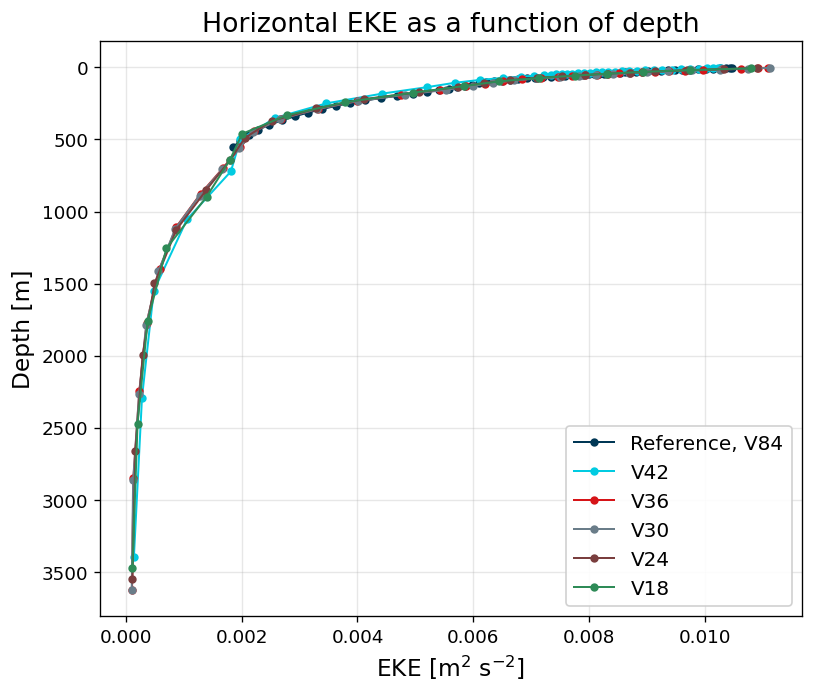

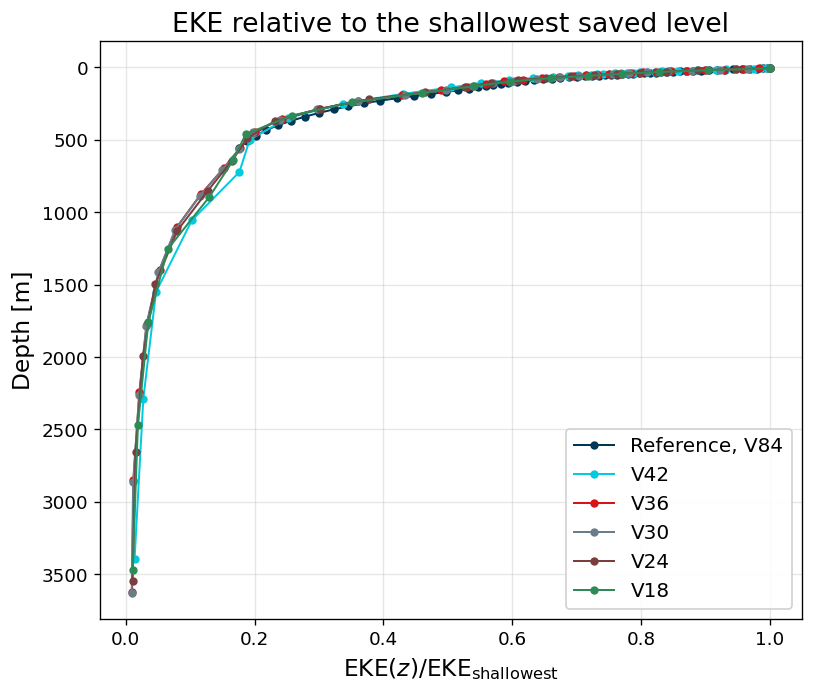

In [15]:
# ============================================================
# ABSOLUTE EKE PROFILE
# ============================================================

fig, ax = plt.subplots(figsize=(7, 6))

for label, p in profiles.items():
    ax.plot(
        p["eke_m2_s2"],
        p["depth_m"],
        marker="o",
        ms=4,
        label=label,
    )

ax.set_xlabel(r"EKE [m$^2$ s$^{-2}$]")
ax.set_ylabel("Depth [m]")
ax.set_title("Horizontal EKE as a function of depth")
ax.invert_yaxis()
ax.grid(True, alpha=0.3)

if MAX_PLOT_DEPTH_M is not None:
    ax.set_ylim(MAX_PLOT_DEPTH_M, 0)

if len(profiles) > 1:
    ax.legend()

plt.tight_layout()
plt.show()


# ============================================================
# NORMALIZED EKE PROFILE
# ============================================================

fig, ax = plt.subplots(figsize=(7, 6))

for label, p in profiles.items():
    ax.plot(
        p["eke_normalized"],
        p["depth_m"],
        marker="o",
        ms=4,
        label=label,
    )

ax.set_xlabel(r"EKE$(z)$/EKE$_{\mathrm{shallowest}}$")
ax.set_ylabel("Depth [m]")
ax.set_title("EKE relative to the shallowest saved level")
ax.invert_yaxis()
ax.grid(True, alpha=0.3)

if MAX_PLOT_DEPTH_M is not None:
    ax.set_ylim(MAX_PLOT_DEPTH_M, 0)

if len(profiles) > 1:
    ax.legend()

plt.tight_layout()
plt.show()
